In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
df = pd.read_csv("dataset/football_matches_dataset.csv")

In [4]:
clean_df = df.drop(columns=["Unnamed: 0"])

In [5]:
clean_df["datetime"] = pd.to_datetime(clean_df["datetime"])

In [6]:
conditions = [
    clean_df["home_score"] > clean_df["away_score"],
    clean_df["home_score"] < clean_df["away_score"]
]

choices = [
    "Home Win",
    "Away Win"
]

clean_df["match_result"] = np.select(
    conditions,
    choices,
    default="Draw"
)

#this step it could be done with a for loop (was my firts test actually), but choosing np.select() will improve speed and let me apply pandas.   BORRAR
# np.select(condlist, choicelist, default=...) variables as condition and chioces, are not reserved words for this np function, we could use a,b. 
# BUT Without specifying default, np.select() uses 0 as the default value. 

In [7]:
clean_df["goal_difference"] = clean_df["home_score"] - clean_df["away_score"]

#### Univariate Analysis

16332 rows - games from european leagues (bl, La Liga etc) Q3 2014 - Q2 2023 

* Relevant variables:

(from kaggle.com description of dataset)
- 11-12 - current standings (table positions) home/away team just before the start of the match
- (not 15-16 - total number of points home/away team have gained in their previous 4 matches)
- 19-20 - total number of goals home/away team have scored in their previous 4 matches 
- 23-24 - total number of goals home/away team have conceded (goals against) in their previous 4 matches
- (27-30 - average value of xG home/away team have gained in their previous 4 matches)

(each) - can be NaN in case of the first matches of the season when teams have not played enough matches this season yet


In [8]:
clean_df.match_result.value_counts()

match_result
Home Win    7270
Away Win    4975
Draw        4087
Name: count, dtype: int64

In [9]:
clean_df["home_score"].value_counts()
clean_df["away_score"].value_counts()

away_score
1    5745
0    5138
2    3304
3    1415
4     519
5     151
6      44
7      11
8       3
9       2
Name: count, dtype: int64

The Propability of scoring is 0.77 for Home Team.

The Propability of scoring is 0.68 for Away Team.

In [10]:
clean_df["match_result"].value_counts()

total_matches = clean_df.shape[0]

clean_df["match_result"].value_counts()['Home Win'] / total_matches, clean_df["match_result"].value_counts()['Draw'] / total_matches, clean_df["match_result"].value_counts()['Away Win'] / total_matches

(np.float64(0.44513837864315453),
 np.float64(0.25024491795248593),
 np.float64(0.30461670340435953))

The Propability of winning is 0.45 for Home Team.

The Probability of winning is 0.25 for Away Team.

The Probability of a Draw is 0.3.



C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_20348\2789291697.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


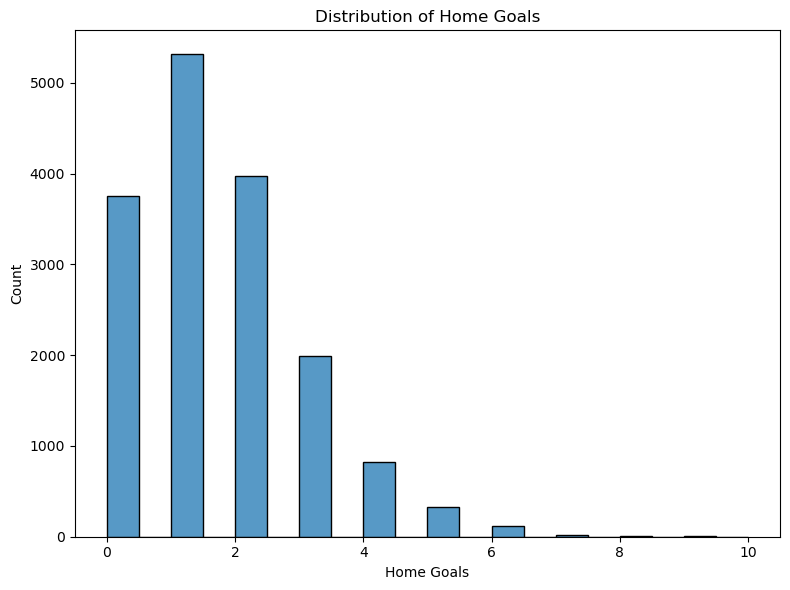

In [11]:
# Summary 
#clean_df["home_goals"].describe()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.histplot(
    data=clean_df,
    x='home_score',
    #hue='match_result',
    bins=20,
    palette={'Home Win':'skyblue','Draw':'lightgreen','Away Win':'salmon'},
    multiple='stack',
    edgecolor='black'
)
plt.xlabel('Home Goals')
plt.ylabel('Count')
plt.title('Distribution of Home Goals')
plt.tight_layout()

C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_20348\3761942446.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


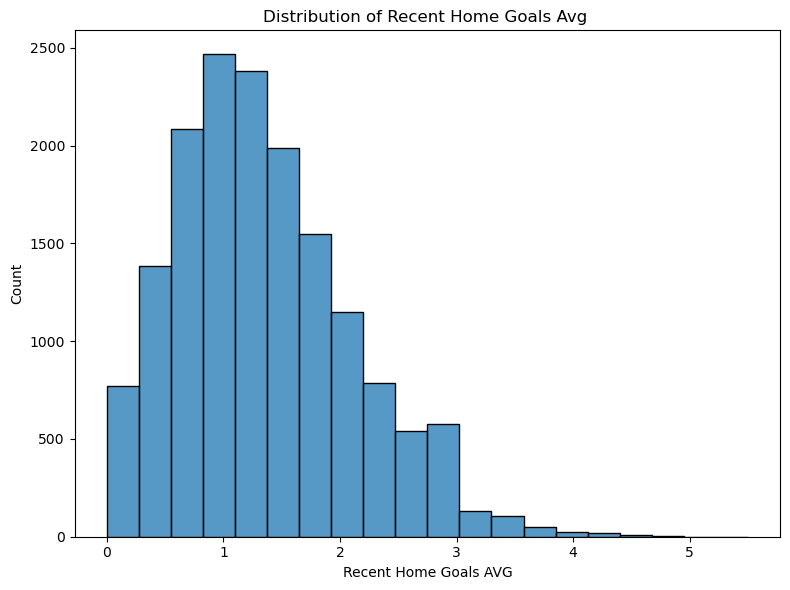

In [12]:
# Summary and create average column
clean_df["home_goals_last_4_matches"].describe()
clean_df["home_goals_last_4_matches_avg"] = clean_df["home_goals_last_4_matches"].mul(0.25)

clean_df["home_goals_last_4_matches_avg"].describe()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.histplot(
    data=clean_df,
    x='home_goals_last_4_matches_avg',
    #hue='match_result',
    bins=20,
    palette={'Home Win':'skyblue','Draw':'lightgreen','Away Win':'salmon'},
    multiple='stack',
    edgecolor='black'
)
plt.xlabel('Recent Home Goals AVG')
plt.ylabel('Count')
plt.title('Distribution of Recent Home Goals Avg ')
plt.tight_layout()

##### combined columns (like match_result)

In [13]:
### difference between home and away standings
clean_df['pos_diff'] = clean_df['home_standings'] - clean_df['away_standings']
clean_df['pos_diff'].describe()

count    16332.000000
mean         0.136909
std          7.858774
min        -19.000000
25%         -6.000000
50%          1.000000
75%          6.000000
max         19.000000
Name: pos_diff, dtype: float64

count    16332.000000
mean         0.136909
std          7.858774
min        -19.000000
25%         -6.000000
50%          1.000000
75%          6.000000
max         19.000000
Name: pos_diff, dtype: float64

Due to modus of the tournament are min and max of differential standings +-19.
Mean is 0, Median is 1 - 50% of ranking differences are between +- 6 Rankings.

Thought: the velocity per team might be a meassure for attractiveness of a competition

### recent_form_difference
sums up scores (goals) of last_4_matches

The original implementation explored two different ways of measuring recent form:

- Using the total points from the last 4 matches.
- Using the goal balance from the last 4 matches.

However, neither approach was completed as the final feature, and both calculations combined the values from the home and away teams instead of comparing them.

Since our Research Question is:

> **2. Does recent team performance influence match outcomes?**

 Why? The dataset contains extensive information about recent team performance.

 Main Variables: Previous Points, Previous Goals Scored, Previous Goals Conceded,
 Previous xG, Match Result, League.

 Possible Analysis: Team form, winning probability and performance trends.

-> we need to compare the recent form of both teams before the match.

For this reason, we calculate:

```python
clean_df["recent_form_difference"] = (
    clean_df["home_points_last_4_matches"]
    - clean_df["away_points_last_4_matches"]
)
```

This feature is easier to interpret:

- Positive values → Home team was in better recent form.
- Negative values → Away team was in better recent form.
- Values close to zero → Both teams had similar recent form.

This implementation better matches the objective of Research Question 2.


In [14]:
# Speaking of Points - Form could be calculated as the sum of the last 4 matches points (a+h) 
newcol = clean_df.home_points_last_4_matches - clean_df.away_points_last_4_matches

# Speaking of Scores - Form could be calculated as the sum of the last 4 matches scores: (a+h) 
newcola = clean_df.away_goals_last_4_matches - clean_df.away_goals_against_last_4_matches
newcolh = clean_df.home_goals_last_4_matches - clean_df.home_goals_against_last_4_matches

newcols = newcolh - newcola
newcols.shape
type(newcols)
#newcols.tail(10)
clean_df["recent_form_difference"] = newcols

#print(clean_df["recent_form_difference"].tail(10))

clean_df["recent_form_difference"] = (
    clean_df["home_points_last_4_matches"]
    - clean_df["away_points_last_4_matches"]
)


<Axes: xlabel='goal_difference'>

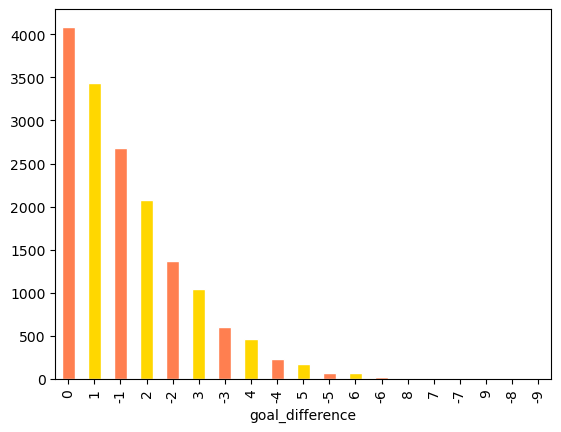

In [15]:
clean_df['goal_difference'].value_counts().plot(kind='bar', color=['coral', 'gold'], edgecolor='white')

##### bivariate Analysis

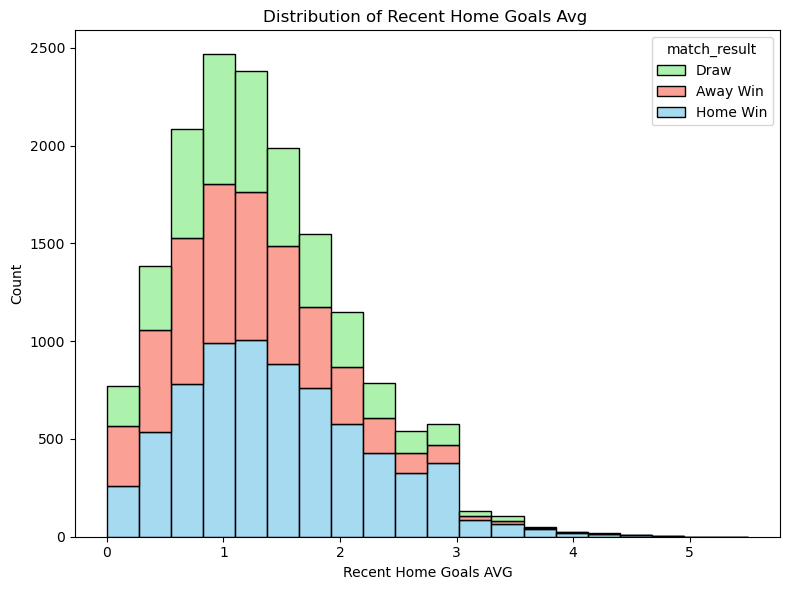

In [16]:
# Summary and create average column
clean_df["home_goals_last_4_matches"].describe()
clean_df["home_goals_last_4_matches_avg"] = clean_df["home_goals_last_4_matches"].mul(0.25)

clean_df["home_goals_last_4_matches_avg"].describe()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.histplot(
    data=clean_df,
    x='home_goals_last_4_matches_avg',
    hue='match_result',
    bins=20,
    palette={'Home Win':'skyblue','Draw':'lightgreen','Away Win':'salmon'},
    multiple='stack',
    edgecolor='black'
)
plt.xlabel('Recent Home Goals AVG')
plt.ylabel('Count')
plt.title('Distribution of Recent Home Goals Avg ')
plt.tight_layout()

create an categorical columns respondig sign and 0 of recent_form_difference

In [17]:
import numpy as np

# Definiere die Bedingungen
conditions = [
    clean_df["recent_form_difference"] > 0,
    clean_df["recent_form_difference"] < 0,
    clean_df["recent_form_difference"] == 0
]

# Definiere die dazugehörigen Ausgaben
choices = ["Home Win", "Away Win", "Draw"]

# Wende np.select an, um die neue Spalte zu erstellen
clean_df["recent_form_difference_ten"] = np.select(conditions, choices, default="")

# Kurze Kontrolle, ob es geklappt hat:
print(clean_df[["recent_form_difference", "recent_form_difference_ten"]].tail())

       recent_form_difference recent_form_difference_ten
16327                     2.0                   Home Win
16328                    -3.0                   Away Win
16329                    -2.0                   Away Win
16330                    -3.0                   Away Win
16331                     2.0                   Home Win


In [18]:
pd.crosstab(clean_df["recent_form_difference_ten"] ,clean_df["match_result"] )

match_result,Away Win,Draw,Home Win
recent_form_difference_ten,,,
,140,130,159
Away Win,2872,1895,2653
Draw,471,410,739
Home Win,1492,1652,3719


The recent form predicts 

a Home Win with certainty

3719 / (1492 + 1652 + 3719) = <span style="color:red">0.54</span>

an Away Win with certainty

2872 / (2872+ 1895 + 2653) = 0.38

and a Draw with certainty

410 / (471 + 410 + 739) = 0.25


The Propability of winning is 0.45 for Home Team.

The Probability of winning is 0.25 for Away Team.

The Probability of a Draw is 0.3.

agent's opinion:
RQ2 (Recent Form vs Outcome): Showed a clear increase in home win probability (54.19% vs <span style="color:orange">35.75%</span>) when the home team is in better recent form.


recent form tendence applied to xG

In [19]:
clean_df["recent_xG_difference"] = (
    clean_df["home_mean_xg_last_4_matches"]
    - clean_df["away_mean_xg_last_4_matches"]
)


# Definiere die Bedingungen
conditions = [
    clean_df["recent_xG_difference"] > 0,
    clean_df["recent_xG_difference"] < 0,
    clean_df["recent_xG_difference"] == 0
]

# Definiere die dazugehörigen Ausgaben
choices = ["xGHome Win", "xGAway Win", "xGDraw"]

# Wende np.select an, um die neue Spalte zu erstellen
clean_df["recent_xG_difference_ten"] = np.select(conditions, choices, default="")

# Kurze Kontrolle, ob es geklappt hat:
print(clean_df[["recent_xG_difference", "recent_xG_difference_ten"]].tail())

       recent_xG_difference recent_xG_difference_ten
16327                 0.565               xGHome Win
16328                -0.110               xGAway Win
16329                 0.155               xGHome Win
16330                -0.480               xGAway Win
16331                 0.320               xGHome Win


In [24]:
import numpy as np

# Definiere die Bedingungen
conditions = [
    clean_df["recent_xG_difference"] > 0,
    clean_df["recent_xG_difference"] < 0,
    clean_df["recent_xG_difference"] == 0
]

# Definiere die dazugehörigen Ausgaben
choices = ["xgHome Win", "xgAway Win", "xgDraw"]

# Wende np.select an, um die neue Spalte zu erstellen
clean_df["recent_xG_difference_ten"] = np.select(conditions, choices, default="")

# Kurze Kontrolle, ob es geklappt hat:
print(clean_df[["recent_xG_difference", "recent_xG_difference_ten"]].tail())

       recent_xG_difference recent_xG_difference_ten
16327                 0.565               xgHome Win
16328                -0.110               xgAway Win
16329                 0.155               xgHome Win
16330                -0.480               xgAway Win
16331                 0.320               xgHome Win


In [25]:
ctxG = pd.crosstab(clean_df["recent_xG_difference_ten"], clean_df["match_result"]).T
ctxG

recent_xG_difference_ten,,xgAway Win,xgDraw,xgHome Win
match_result,,,,
Away Win,140,3218,8,1609
Draw,130,2140,3,1814
Home Win,159,2847,7,4257


In [28]:
pxGisRightL = ctxG['xgAway Win'][0] / (ctxG['xgAway Win'][1] + ctxG['xgAway Win'][2] + ctxG['xgAway Win'][0])
#pxGisRightW = ctxG['xgAway Win'][1] / (ctxG['xgAway Win'][1] + ctxG['xgAway Win'][2] + ctxG['xgAway Win'][0])
#pxGisRightW = ctxG['xgAway Win'][2] / (ctxG['xgAway Win'][1] + ctxG['xgAway Win'][2] + ctxG['xgAway Win'][0])

pxGisRightW =ctxG['xgHome Win'][2] / (ctxG['xgHome Win'][1] + ctxG['xgHome Win'][2] + ctxG['xgHome Win'][0])
#ctxG['xgHome Win'][1] / (ctxG['xgHome Win'][1] + ctxG['xgHome Win'][2] + ctxG['xgHome Win'][0])
#ctxG['xgHome Win'][2] / (ctxG['xgHome Win'][1] + ctxG['xgHome Win'][2] + ctxG['xgHome Win'][0])

pxGisRightD = ctxG['xgDraw'][1] / (ctxG['xgDraw'][1] + ctxG['xgDraw'][2] + ctxG['xgDraw'][0])
#ctxG['xgDraw'][1] / (ctxG['xgDraw'][1] + ctxG['xgDraw'][2] + ctxG['xgDraw'][0])
#ctxG['xgDraw'][2] / (ctxG['xgDraw'][1] + ctxG['xgDraw'][2] + ctxG['xgDraw'][0])

pxGisRightW,pxGisRightD,pxGisRightL



C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_20348\2573662017.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pxGisRightL = ctxG['xgAway Win'][0] / (ctxG['xgAway Win'][1] + ctxG['xgAway Win'][2] + ctxG['xgAway Win'][0])
C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_20348\2573662017.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pxGisRightW =ctxG['xgHome Win'][2] / (ctxG['xgHome Win'][1] + ctxG['xgHome Win'][2] + ctxG['xgHome Win'][0])
C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_20348\2573662017.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, int

(np.float64(0.554296875),
 np.float64(0.16666666666666666),
 np.float64(0.39219987812309565))

Seems like: recent xG does predict draws better, BUT very small values!!! -> incorrect result :(